# POD Analysis V2 (Notebook Modular)

Execute as cÃƒÂ©lulas em ordem (Etapa 1 Ã¢â€ â€™ Etapa 4).
Cada etapa representa um bloco independente do pipeline.


In [1]:
from __future__ import annotations

import os
from pathlib import Path
from datetime import datetime
from typing import Optional, Dict, Tuple, List

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.interpolate import griddata


In [2]:
# =========================
# CONFIG (AJUSTE AQUI)
# =========================

DEFAULT_SRC_DIR = Path(r"C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\src")
THIS_DIR = Path(__file__).resolve().parent if "__file__" in globals() else DEFAULT_SRC_DIR
CASE_DIR = THIS_DIR.parent.parent
OUT_DIR  = THIS_DIR.parent / "resultados"

FIELD_NAME = "U"
MESH_TIME_NAME = None
STRUCTURED = False

USE_ALL_TIMES = True
TIME_START = None
TIME_END   = None
TIME_STEP  = 1

RMAX: Optional[int] = 50
R_LIST: Optional[List[int]] = None
CENTER_DATA = True
NORMALIZE_SNAPSHOTS = True

GRID_NX = 220
GRID_NY = 220
GRID_METHOD = "linear"
GRID_PADDING = 0.02
MODE_PLOT_MAX = 10
RECON_TOPK = 5

USE_ROI = False
ROI_XMIN = None
ROI_XMAX = None
ROI_YMIN = None
ROI_YMAX = None

SEED = 7
TEST_FRACTION = 0.1

print(f"THIS_DIR: {THIS_DIR}")
print(f"CASE_DIR: {CASE_DIR}")
print(f"OUT_DIR : {OUT_DIR}")


THIS_DIR: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\src
CASE_DIR: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000
OUT_DIR : C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados


In [3]:
try:
    from fluidfoam import readmesh, readfield
except Exception as e:
    raise ImportError(
        "N\u00e3o foi poss\u00edvel importar fluidfoam. Instale e/ou ative o ambiente do OpenFOAM.\n"
        "pip install fluidfoam\n\nErro original:\n"
        f"{e}"
    )


In [4]:
def ensure_dir(p: Path) -> None:
    p.mkdir(parents=True, exist_ok=True)

def list_time_dirs(case_dir: Path) -> List[str]:
    times = []
    for item in case_dir.iterdir():
        if item.is_dir():
            name = item.name
            try:
                float(name)
                times.append(name)
            except:
                pass
    times.sort(key=lambda s: float(s))
    return times

def filter_times(times: List[str]) -> List[str]:
    if not times:
        return times

    out = times

    if TIME_START is not None:
        out = [t for t in out if float(t) >= float(TIME_START)]
    if TIME_END is not None:
        out = [t for t in out if float(t) <= float(TIME_END)]

    out = out[:: max(1, int(TIME_STEP))]
    return out

def read_mesh_xy(case_dir: Path) -> Tuple[np.ndarray, np.ndarray]:
    mesh = readmesh(str(case_dir), time_name=MESH_TIME_NAME, structured=STRUCTURED)
    if isinstance(mesh, (tuple, list)) and len(mesh) >= 2:
        x = np.asarray(mesh[0]).ravel()
        y = np.asarray(mesh[1]).ravel()
        return x, y
    mesh = np.asarray(mesh)
    if mesh.ndim == 2 and mesh.shape[1] >= 2:
        return mesh[:, 0].ravel(), mesh[:, 1].ravel()
    raise ValueError("NÃƒÂ£o consegui interpretar a malha (x,y) via fluidfoam.readmesh().")

def read_U_components(case_dir: Path, time_name: str, nCells: int) -> Tuple[np.ndarray, np.ndarray]:
    Uf = readfield(str(case_dir), time_name, FIELD_NAME)
    Uf = np.asarray(Uf)

    if Uf.ndim == 2 and Uf.shape == (3, 1):
        Ux = np.full(nCells, float(Uf[0, 0]), dtype=float)
        Uy = np.full(nCells, float(Uf[1, 0]), dtype=float)
        return Ux, Uy

    if Uf.ndim == 2 and Uf.shape[0] == 3 and Uf.shape[1] == nCells:
        return Uf[0, :].astype(float), Uf[1, :].astype(float)

    if Uf.ndim == 2 and Uf.shape[0] == nCells and Uf.shape[1] >= 2:
        return Uf[:, 0].astype(float), Uf[:, 1].astype(float)

    if Uf.ndim == 1:
        if Uf.size == 3 * nCells:
            Uf2 = Uf.reshape(nCells, 3)
            return Uf2[:, 0].astype(float), Uf2[:, 1].astype(float)

    raise ValueError(
        f"Formato inesperado do campo U no tempo {time_name}: shape={Uf.shape}, nCells={nCells}"
    )

def make_grid(x: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray, Tuple[float,float,float,float]]:
    xmin, xmax = float(np.min(x)), float(np.max(x))
    ymin, ymax = float(np.min(y)), float(np.max(y))
    dx = (xmax - xmin) * GRID_PADDING
    dy = (ymax - ymin) * GRID_PADDING
    xmin -= dx; xmax += dx
    ymin -= dy; ymax += dy
    gx = np.linspace(xmin, xmax, GRID_NX)
    gy = np.linspace(ymin, ymax, GRID_NY)
    Xg, Yg = np.meshgrid(gx, gy)
    return Xg, Yg, (xmin, xmax, ymin, ymax)

def interp_to_grid(x: np.ndarray, y: np.ndarray, val: np.ndarray, Xg: np.ndarray, Yg: np.ndarray) -> np.ndarray:
    pts = np.column_stack([x, y])
    Vg = griddata(pts, val, (Xg, Yg), method=GRID_METHOD)
    if np.isnan(Vg).any():
        Vn = griddata(pts, val, (Xg, Yg), method="nearest")
        Vg = np.where(np.isnan(Vg), Vn, Vg)
    return Vg

def apply_roi_mask(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    mask = np.ones_like(x, dtype=bool)
    if ROI_XMIN is not None: mask &= (x >= ROI_XMIN)
    if ROI_XMAX is not None: mask &= (x <= ROI_XMAX)
    if ROI_YMIN is not None: mask &= (y >= ROI_YMIN)
    if ROI_YMAX is not None: mask &= (y <= ROI_YMAX)
    return mask

def safe_rel(a: np.ndarray, b: np.ndarray, eps: float = 1e-12) -> float:
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(a) + eps
    return float(num / den)

def compute_pod_svd(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return U, s, Vt

def reconstruct_from_svd(U: np.ndarray, s: np.ndarray, Vt: np.ndarray, r: int) -> np.ndarray:
    Ur = U[:, :r]
    sr = s[:r]
    Vtr = Vt[:r, :]
    return (Ur * sr) @ Vtr

def analyze_errors(X: np.ndarray, Xmean: np.ndarray, U: np.ndarray, s: np.ndarray, Vt: np.ndarray,
                   times: List[str], x: np.ndarray, y: np.ndarray, out_dir: Path,
                   r_values: List[int]) -> Dict[str, np.ndarray]:
    Nt = X.shape[1]
    nFeat = X.shape[0]

    err_tr = np.zeros((Nt, len(r_values)), dtype=float)
    err_r = np.zeros(len(r_values), dtype=float)

    s2 = s**2
    energy_cum = np.cumsum(s2) / (np.sum(s2) + 1e-18)

    for j, r in enumerate(r_values):
        Xr = reconstruct_from_svd(U, s, Vt, r)
        for t in range(Nt):
            err_tr[t, j] = safe_rel(X[:, t], Xr[:, t])
        err_r[j] = np.linalg.norm(X - Xr) / (np.linalg.norm(X) + 1e-18)

    plt.figure()
    plt.plot(r_values, err_r, marker="o")
    plt.xlabel("r (nÃ‚Âº modos)")
    plt.ylabel("Erro relativo global (Frobenius)")
    plt.title("Erro global vs r")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "err1_global_vs_r.png", dpi=220)
    plt.close()

    plt.figure()
    plt.imshow(err_tr, aspect="auto", origin="lower")
    plt.colorbar(label="Erro relativo por timestep")
    plt.yticks(range(0, Nt, max(1, Nt // 10)), [times[i] for i in range(0, Nt, max(1, Nt // 10))])
    plt.xticks(range(len(r_values)), [str(r) for r in r_values], rotation=45)
    plt.xlabel("r")
    plt.ylabel("timestep")
    plt.title("Heatmap: erro(t, r)")
    plt.tight_layout()
    plt.savefig(out_dir / "err2_heatmap_t_by_r.png", dpi=220)
    plt.close()

    plt.figure()
    energy_at_r = np.array([energy_cum[r-1] if r-1 < len(energy_cum) else 1.0 for r in r_values], dtype=float)
    plt.plot(r_values, energy_at_r, marker="o")
    plt.xlabel("r (nº modos)")
    plt.ylabel("Energia acumulada")
    plt.title("Energia acumulada vs r")
    plt.ylim(0, 1.02)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "err3_energy_cumulative.png", dpi=220)
    plt.close()

    if USE_ROI:
        mask = apply_roi_mask(x, y)
        nCells = x.size
        idx = np.where(mask)[0]
        feat_idx = np.concatenate([idx, idx + nCells])
        err_roi = np.zeros(len(r_values), dtype=float)
        for j, r in enumerate(r_values):
            Xr = reconstruct_from_svd(U, s, Vt, r)
            err_roi[j] = np.linalg.norm(X[feat_idx, :] - Xr[feat_idx, :]) / (np.linalg.norm(X[feat_idx, :]) + 1e-18)

        plt.figure()
        plt.plot(r_values, err_roi, marker="o")
        plt.xlabel("r")
        plt.ylabel("Erro relativo (ROI)")
        plt.title("Erro em ROI vs r")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(out_dir / "err4_roi_vs_r.png", dpi=220)
        plt.close()
    else:
        err_roi = None

    r_final = r_values[-1]
    Xr_final = reconstruct_from_svd(U, s, Vt, r_final)
    err_t_final = np.array([safe_rel(X[:, t], Xr_final[:, t]) for t in range(Nt)], dtype=float)

    plt.figure()
    plt.plot(range(Nt), err_t_final, marker="o")
    plt.xlabel("Index timestep")
    plt.ylabel(f"Erro relativo (r={r_final})")
    plt.title("Erro por timestep (r_final)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "err5_error_by_timestep_rfinal.png", dpi=220)
    plt.close()

    rng = np.random.default_rng(SEED)
    indices = np.arange(Nt)
    rng.shuffle(indices)
    n_test = max(1, int(TEST_FRACTION * Nt))
    test_idx = np.sort(indices[:n_test])
    train_idx = np.sort(indices[n_test:])

    Xtrain = X[:, train_idx]
    Utr, str_, Vttr = compute_pod_svd(Xtrain)
    err_test_r = np.zeros(len(r_values), dtype=float)
    for j, r in enumerate(r_values):
        Ur = Utr[:, :r]
        Xtest = X[:, test_idx]
        coef = Ur.T @ Xtest
        Xhat = Ur @ coef
        err_test_r[j] = np.linalg.norm(Xtest - Xhat) / (np.linalg.norm(Xtest) + 1e-18)

    plt.figure()
    plt.plot(r_values, err_test_r, marker="o")
    plt.xlabel("r")
    plt.ylabel("Erro relativo (teste)")
    plt.title(f"GeneralizaÃƒÂ§ÃƒÂ£o (treino/teste {int(100*TEST_FRACTION)}%)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "err6_train_test_vs_r.png", dpi=220)
    plt.close()

    k = min(r_final, 50, U.shape[1])
    G = U[:, :k].T @ U[:, :k]
    off = G - np.eye(k)
    ortho_measure = np.linalg.norm(off, ord="fro") / (np.linalg.norm(np.eye(k), ord="fro") + 1e-18)

    plt.figure()
    plt.imshow(G, aspect="auto", origin="lower")
    plt.colorbar(label="(U^T U)_{ij}")
    plt.title(f"Gram matrix dos modos (k={k}) | desvio Fro={ortho_measure:.3e}")
    plt.tight_layout()
    plt.savefig(out_dir / "err7_orthogonality_gram.png", dpi=220)
    plt.close()

    metrics = {
        "r_values": np.array(r_values, dtype=int),
        "err_r": err_r,
        "err_tr": err_tr,
        "energy_cum_full": energy_cum,
        "energy_at_r": energy_at_r,
        "err_t_rfinal": err_t_final,
        "err_test_r": err_test_r,
        "orthogonality_fro": np.array([ortho_measure], dtype=float),
        "test_idx": test_idx.astype(int),
        "train_idx": train_idx.astype(int),
    }
    if err_roi is not None:
        metrics["err_roi_r"] = err_roi
    return metrics

def save_mode_heatmaps(U_modes: np.ndarray, x: np.ndarray, y: np.ndarray, out_modes: Path,
                       nCells: int, Xg: np.ndarray, Yg: np.ndarray, n_modes_save: int) -> None:
    ensure_dir(out_modes)

    rmax = U_modes.shape[1]
    nsave = min(n_modes_save, rmax)

    # guarda |U| dos modos para montar painel 1..n
    mode_umag_grids = []

    for k in range(nsave):
        phi = U_modes[:, k]
        phi_x = phi[:nCells]
        phi_y = phi[nCells:2*nCells]
        phi_mag = np.sqrt(phi_x**2 + phi_y**2)

        Vx = interp_to_grid(x, y, phi_x, Xg, Yg)
        Vy = interp_to_grid(x, y, phi_y, Xg, Yg)
        Vm = interp_to_grid(x, y, phi_mag, Xg, Yg)

        mode_umag_grids.append(Vm)

        fig, axs = plt.subplots(1, 3, figsize=(14, 4))
        im0 = axs[0].imshow(Vx, origin="lower", aspect="auto")
        axs[0].set_title(f"Modo {k+1} - Ux")
        plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

        im1 = axs[1].imshow(Vy, origin="lower", aspect="auto")
        axs[1].set_title(f"Modo {k+1} - Uy")
        plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

        im2 = axs[2].imshow(Vm, origin="lower", aspect="auto")
        axs[2].set_title(f"Modo {k+1} - |U|")
        plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

        for a in axs:
            a.set_xticks([]); a.set_yticks([])

        fig.suptitle("Heatmaps dos modos POD (interp griddata)")
        fig.tight_layout()
        fig.savefig(out_modes / f"mode_{k+1:03d}_triplet.png", dpi=220)
        plt.close(fig)

    # figura adicional: fileiras com 5 imagens lado a lado (modos 1..n)
    n_panel = len(mode_umag_grids)
    if n_panel > 0:
        n_cols = 5
        n_rows = int(np.ceil(n_panel / n_cols))

        fig, axs = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 3.2 * n_rows), squeeze=False)

        for idx in range(n_rows * n_cols):
            r = idx // n_cols
            c = idx % n_cols
            ax = axs[r, c]

            if idx < n_panel:
                im = ax.imshow(mode_umag_grids[idx], origin="lower", aspect="auto")
                ax.set_title(f"Modo {idx+1} - |U|", fontsize=10)
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
                ax.set_xticks([]); ax.set_yticks([])
            else:
                ax.axis("off")

        fig.suptitle(f"Painel de modos POD |U| (1..{n_panel}) em fileiras de 5", fontsize=14)
        fig.tight_layout()
        fig.savefig(out_modes / f"modes_01_{n_panel:02d}_panel_umag.png", dpi=220)
        plt.close(fig)

def save_reconstruction_triplets(Xtrue: np.ndarray, Xrecon: np.ndarray, Xmean: np.ndarray,
                                 times: List[str], x: np.ndarray, y: np.ndarray,
                                 out_recon: Path, nCells: int, Xg: np.ndarray, Yg: np.ndarray,
                                 topk: int) -> None:
    ensure_dir(out_recon)

    Nt = Xtrue.shape[1]
    err_t = np.array([safe_rel(Xtrue[:, t], Xrecon[:, t]) for t in range(Nt)], dtype=float)
    worst = np.argsort(-err_t)[: min(topk, Nt)]

    for rank_i, t in enumerate(worst, start=1):
        Xt = Xtrue[:, t] + Xmean
        Xr = Xrecon[:, t] + Xmean
        Xe = Xt - Xr

        Xt_x, Xt_y = Xt[:nCells], Xt[nCells:2*nCells]
        Xr_x, Xr_y = Xr[:nCells], Xr[nCells:2*nCells]
        Xe_x, Xe_y = Xe[:nCells], Xe[nCells:2*nCells]

        Xt_m = np.sqrt(Xt_x**2 + Xt_y**2)
        Xr_m = np.sqrt(Xr_x**2 + Xr_y**2)
        Xe_m = np.sqrt(Xe_x**2 + Xe_y**2)

        grids = {
            "Ux": (Xt_x, Xr_x, Xe_x),
            "Uy": (Xt_y, Xr_y, Xe_y),
            "Umag": (Xt_m, Xr_m, Xe_m),
        }

        for key, (a, b, e) in grids.items():
            A = interp_to_grid(x, y, a, Xg, Yg)
            B = interp_to_grid(x, y, b, Xg, Yg)
            E = interp_to_grid(x, y, np.abs(e), Xg, Yg)

            fig, axs = plt.subplots(1, 3, figsize=(14, 4))
            im0 = axs[0].imshow(A, origin="lower", aspect="auto")
            axs[0].set_title(f"{key} real")
            plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

            im1 = axs[1].imshow(B, origin="lower", aspect="auto")
            axs[1].set_title(f"{key} reconstruÃƒÂ­do")
            plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

            im2 = axs[2].imshow(E, origin="lower", aspect="auto")
            axs[2].set_title(f"|erro| ({key})")
            plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

            for ax in axs:
                ax.set_xticks([]); ax.set_yticks([])

            fig.suptitle(f"Pior timestep #{rank_i}: t={times[t]} | erro_rel={err_t[t]:.3e}")
            fig.tight_layout()
            fig.savefig(out_recon / f"worst_{rank_i:02d}_t{times[t].replace('.','p')}_{key}.png", dpi=220)
            plt.close(fig)


In [5]:
# Etapa 1: prepara saÃƒÂ­das, tempos e malha
ensure_dir(OUT_DIR)
out_modes = OUT_DIR / "fig_modes"
out_recon = OUT_DIR / "fig_recon_piores_timesteps_1_a_5"
ensure_dir(out_modes)
ensure_dir(out_recon)

times_all = list_time_dirs(CASE_DIR)
times = filter_times(times_all)
if not times:
    raise RuntimeError(f"Nenhum diret\u00f3rio de tempo encontrado/selecionado em {CASE_DIR}")

x, y = read_mesh_xy(CASE_DIR)
if x.ndim != 1 or y.ndim != 1:
    raise ValueError(f"Malha inv\u00e1lida: x.ndim={x.ndim}, y.ndim={y.ndim}. Esperado vetores 1D.")
if x.size != y.size:
    raise ValueError(f"Malha inconsistente: x.size={x.size} != y.size={y.size}")

nCells = x.size
if nCells <= 0:
    raise ValueError("N\u00famero de c\u00e9lulas inv\u00e1lido: nCells <= 0")

Xg, Yg, _bbox = make_grid(x, y)
Nt = len(times)
Xsnap = np.zeros((2 * nCells, Nt), dtype=float)

print("[CHECK] MALHA")
print(f"x.shape = {x.shape}")
print(f"y.shape = {y.shape}")
print(f"nCells  = {nCells}")
print("[CHECK] GRID")
print(f"Xg.shape = {Xg.shape}")
print(f"Yg.shape = {Yg.shape}")
print("[CHECK] SNAPSHOTS")
print(f"Nt = {Nt}")
print(f"Xsnap.shape = {Xsnap.shape}")


Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000/constant/polyMesh/owner
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000/constant/polyMesh/faces
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000/constant/polyMesh/points
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000/constant/polyMesh/neighbour
[CHECK] MALHA
x.shape = (2268,)
y.shape = (2268,)
nCells  = 2268
[CHECK] GRID
Xg.shape = (220, 220)
Yg.shape = (220, 220)
[CHECK] SNAPSHOTS
Nt = 1001
Xsnap.shape = (4536, 1001)


In [6]:
# Etapa 2: carrega snapshots e faz prÃƒÂ©-processamento
for i, tname in enumerate(times):
    Ux, Uy = read_U_components(CASE_DIR, tname, nCells)

    if Ux.ndim != 1 or Uy.ndim != 1:
        raise ValueError(
            f"Campo U inv\u00e1lido em {tname}: Ux.ndim={Ux.ndim}, Uy.ndim={Uy.ndim}. Esperado vetores 1D."
        )
    if Ux.size != nCells or Uy.size != nCells:
        raise ValueError(
            f"Tamanho inconsistente de U em {tname}: Ux={Ux.size}, Uy={Uy.size}, nCells={nCells}"
        )

    Xsnap[:nCells, i] = Ux
    Xsnap[nCells:2*nCells, i] = Uy

print(f"Xsnap.shape (preenchido) = {Xsnap.shape}")

if NORMALIZE_SNAPSHOTS:
    norms = np.linalg.norm(Xsnap, axis=0) + 1e-18
    Xsnap = Xsnap / norms
    print("NORMALIZE_SNAPSHOTS = True")
    print(f"norms.shape = {norms.shape}")
else:
    print("NORMALIZE_SNAPSHOTS = False")

Xmean = np.zeros((2 * nCells,), dtype=float)
X = Xsnap.copy()

if CENTER_DATA:
    Xmean = np.mean(Xsnap, axis=1)
    X = Xsnap - Xmean[:, None]

print(f"CENTER_DATA = {CENTER_DATA}")
print(f"Xmean.shape = {Xmean.shape}")
print(f"X.shape     = {X.shape}")


Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\0\U

Only constant field in output

Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\0.001\U
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\0.002\U
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\0.003\U
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\0.004\U
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\0.005\U
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\0.006\U
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\0.007\U
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\0.008\U
Reading file C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\0.009\U
Reading file C:\Users\

In [7]:
# Etapa 3: POD/SVD, escolha de r e saÃƒÂ­das bÃƒÂ¡sicas
U, s, Vt = compute_pod_svd(X)
rank = len(s)

print("[CHECK] SVD")
print(f"U.shape  = {U.shape}")
print(f"s.shape  = {s.shape}")
print(f"Vt.shape = {Vt.shape}")
print(f"rank     = {rank}")

if R_LIST is not None:
    r_values = sorted({int(r) for r in R_LIST if int(r) >= 1})
    if not r_values:
        raise ValueError("R_LIST foi definido, mas n\u00e3o possui valores v\u00e1lidos >= 1")
    if max(r_values) > rank:
        raise ValueError(f"R_LIST cont\u00e9m valor maior que o rank: max(R_LIST)={max(r_values)} > rank={rank}")
    rmax_use = max(r_values)
else:
    rmax_use = rank if RMAX is None else min(int(RMAX), rank)
    r_values = list(range(1, rmax_use + 1))

print(f"rmax_use = {rmax_use}")
print(f"r_final  = {r_values[-1]}")

energy = (s**2) / (np.sum(s**2) + 1e-18)
cum_energy = np.cumsum(energy)

plt.figure()
n_energy = min(rmax_use, len(cum_energy))
plt.plot(range(1, n_energy + 1), cum_energy[:n_energy], marker="o")
plt.xlabel("Modo")
plt.ylabel("Energia acumulada")
plt.title("Energia acumulada (POD)")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "pod_energy.png", dpi=220)
plt.close()

A = (s[:, None] * Vt)

nm = min(10, A.shape[0])
plt.figure(figsize=(10, 5))
for k in range(nm):
    plt.plot(A[k, :], label=f"mode {k+1}")
plt.xlabel("Index timestep")
plt.ylabel("Coeficiente")
plt.title("Coeficientes POD (primeiros modos)")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "pod_coefficients.png", dpi=220)
plt.close()

np.savez(
    OUT_DIR / "pod_results.npz",
    U=U, s=s, Vt=Vt,
    times=np.array(times),
    x=x, y=y,
    Xmean=Xmean,
    centered=np.array([CENTER_DATA], dtype=bool),
)

print(f"Resultados parciais salvos em: {OUT_DIR}")


[CHECK] SVD
U.shape  = (4536, 1001)
s.shape  = (1001,)
Vt.shape = (1001, 1001)
rank     = 1001
rmax_use = 50
r_final  = 50
Resultados parciais salvos em: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados


In [8]:
# Etapa 4: anÃƒÂ¡lises de erro, heatmaps, reconstruÃƒÂ§ÃƒÂ£o e saÃƒÂ­da final
metrics = analyze_errors(X, Xmean, U, s, Vt, times, x, y, OUT_DIR, r_values)

save_mode_heatmaps(
    U_modes=U[:, :rmax_use],
    x=x, y=y,
    out_modes=out_modes,
    nCells=nCells,
    Xg=Xg, Yg=Yg,
    n_modes_save=min(MODE_PLOT_MAX, rmax_use),
)

r_final = r_values[-1]
Xrecon = reconstruct_from_svd(U, s, Vt, r_final)

err_global_rfinal = np.linalg.norm(X - Xrecon) / (np.linalg.norm(X) + 1e-18)
err_t_rfinal = np.array([safe_rel(X[:, t], Xrecon[:, t]) for t in range(Nt)], dtype=float)

save_reconstruction_triplets(
    Xtrue=X,
    Xrecon=Xrecon,
    Xmean=Xmean,
    times=times,
    x=x, y=y,
    out_recon=out_recon,
    nCells=nCells,
    Xg=Xg, Yg=Yg,
    topk=RECON_TOPK,
)

np.savez(
    OUT_DIR / "pod_with_7_error_analyses_plus_heatmaps.npz",
    times=np.array(times),
    x=x, y=y,
    Xsnap=Xsnap,
    Xcentered=X,
    Xmean=Xmean,
    centered=np.array([CENTER_DATA], dtype=bool),
    U=U, s=s, Vt=Vt,
    A=A,
    Xrecon=Xrecon,
    err_global_rfinal=np.array([err_global_rfinal], dtype=float),
    err_t_rfinal_check=err_t_rfinal,
    nCells=np.array([nCells], dtype=int),
    Nt=np.array([Nt], dtype=int),
    rank=np.array([rank], dtype=int),
    r_final=np.array([r_final], dtype=int),
    **metrics,
)

print("OK! POD melhorado finalizado com checagem dimensional.")
print(f"Sai­das em: {OUT_DIR}")
print("- Curvas/erros: err1_..err7_*.png")
print(f"- Modos: {out_modes}/mode_###_triplet.png")
print(f"- Reconstrustrucoes (5 piores timesteps): {out_recon}/worst_##_t*_*.png")
print(f"- NPZ completo: {OUT_DIR / 'pod_with_7_error_analyses_plus_heatmaps.npz'}")


OK! POD melhorado finalizado com checagem dimensional.
Sai­das em: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados
- Curvas/erros: err1_..err7_*.png
- Modos: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\fig_modes/mode_###_triplet.png
- Reconstrustrucoes (5 piores timesteps): C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\fig_recon_piores_timesteps_1_a_5/worst_##_t*_*.png
- NPZ completo: C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\pod_with_7_error_analyses_plus_heatmaps.npz


In [13]:
# ============================================================
# POD: imagens desnormalizadas para tempos exatos 0, 0.25, 0.50, 0.75, 1.0
# Layout 3x3: (Ux, Uy, U) x (true, recon, err)
# ============================================================
targets = np.array([0.00, 0.25, 0.50, 0.75, 1.00], dtype=float)
tol = 1e-6

required = ["OUT_DIR", "times", "Xsnap", "Xmean", "nCells", "x", "y", "CENTER_DATA", "NORMALIZE_SNAPSHOTS"]
missing_req = [k for k in required if k not in globals()]
if missing_req:
    raise RuntimeError(f"Variaveis POD ausentes: {missing_req}")

# Reconstrucao POD (se ainda nao estiver em memoria)
if "Xrecon" not in globals():
    if "r_final" in globals():
        rr = int(r_final)
    elif "r_values" in globals():
        rr = int(r_values[-1])
    else:
        raise RuntimeError("Nao encontrei Xrecon nem r_final/r_values para reconstruir.")
    Xrecon = reconstruct_from_svd(U, s, Vt, rr)

# Grid para visualizacao
if "Xg" not in globals() or "Yg" not in globals():
    Xg, Yg, _bbox = make_grid(x, y)

# Tempos como float
times_float = np.array([float(str(tt).strip()) for tt in times], dtype=float)

# Escala para desnormalizar snapshot (caso NORMALIZE_SNAPSHOTS=True)
if bool(NORMALIZE_SNAPSHOTS):
    if "norms" not in globals():
        raise RuntimeError("NORMALIZE_SNAPSHOTS=True, mas 'norms' nao esta em memoria para desnormalizar.")
    norms_vec = np.asarray(norms, dtype=float).ravel()
    if norms_vec.size != Xsnap.shape[1]:
        raise ValueError(f"norms.size={norms_vec.size} diferente de Nt={Xsnap.shape[1]}")
else:
    norms_vec = np.ones(Xsnap.shape[1], dtype=float)

# Pasta nova para nao misturar com execucoes antigas
run_tag = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
out_dir = Path(OUT_DIR) / f"tempos_0a_1_pod_{run_tag}"
out_dir.mkdir(parents=True, exist_ok=False)
print(f"[PASTA NOVA] {out_dir}")

def save_img_3x3_pod(Xt_phys: np.ndarray, Xr_phys: np.ndarray, outpath: Path, title: str) -> None:
    Xt_x = Xt_phys[:nCells]
    Xt_y = Xt_phys[nCells:2*nCells]
    Xr_x = Xr_phys[:nCells]
    Xr_y = Xr_phys[nCells:2*nCells]

    Xt_u = np.sqrt(Xt_x**2 + Xt_y**2)
    Xr_u = np.sqrt(Xr_x**2 + Xr_y**2)

    Ex_x = Xr_x - Xt_x
    Ex_y = Xr_y - Xt_y
    Ex_u = Xr_u - Xt_u

    A1 = interp_to_grid(x, y, Xt_x, Xg, Yg)
    B1 = interp_to_grid(x, y, Xr_x, Xg, Yg)
    E1 = interp_to_grid(x, y, Ex_x, Xg, Yg)

    A2 = interp_to_grid(x, y, Xt_y, Xg, Yg)
    B2 = interp_to_grid(x, y, Xr_y, Xg, Yg)
    E2 = interp_to_grid(x, y, Ex_y, Xg, Yg)

    A3 = interp_to_grid(x, y, Xt_u, Xg, Yg)
    B3 = interp_to_grid(x, y, Xr_u, Xg, Yg)
    E3 = interp_to_grid(x, y, Ex_u, Xg, Yg)

    fig, ax = plt.subplots(3, 3, figsize=(12, 9))

    ax[0, 0].imshow(A1, origin="lower"); ax[0, 0].set_title("Ux true")
    ax[0, 1].imshow(B1, origin="lower"); ax[0, 1].set_title("Ux recon")
    ax[0, 2].imshow(E1, origin="lower"); ax[0, 2].set_title("Ux err")

    ax[1, 0].imshow(A2, origin="lower"); ax[1, 0].set_title("Uy true")
    ax[1, 1].imshow(B2, origin="lower"); ax[1, 1].set_title("Uy recon")
    ax[1, 2].imshow(E2, origin="lower"); ax[1, 2].set_title("Uy err")

    ax[2, 0].imshow(A3, origin="lower"); ax[2, 0].set_title("U true")
    ax[2, 1].imshow(B3, origin="lower"); ax[2, 1].set_title("U recon")
    ax[2, 2].imshow(E3, origin="lower"); ax[2, 2].set_title("U err")

    for i in range(3):
        for j in range(3):
            ax[i, j].axis("off")

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(outpath, dpi=220)
    plt.close(fig)

print("=== POD: TEMPOS EXATOS (0.00, 0.25, 0.50, 0.75, 1.00) ===")
missing_times = []

for tt in targets:
    hits = np.flatnonzero(np.isclose(times_float, tt, atol=tol, rtol=0.0))

    if hits.size == 0:
        missing_times.append(float(tt))
        print(f"[MISSING] t={tt:g} nao existe exatamente em times")
        continue

    if hits.size > 1:
        print(f"[DUPLICADO] t={tt:g} em times: idx={hits.tolist()} (usando o primeiro)")

    i = int(hits[0])

    Xt_snap = np.asarray(Xsnap[:, i], dtype=float)
    Xr_snap = np.asarray(Xrecon[:, i], dtype=float)
    if bool(CENTER_DATA):
        Xr_snap = Xr_snap + np.asarray(Xmean, dtype=float)

    scale_i = float(norms_vec[i])
    Xt_phys = Xt_snap * scale_i
    Xr_phys = Xr_snap * scale_i

    rel_p = np.linalg.norm(Xr_phys - Xt_phys) / (np.linalg.norm(Xt_phys) + 1e-12)
    label_tt = f"{tt:.2f}".replace(".", "p")
    title = f"tempo={tt:.2f} | tempo reconstruido={times_float[i]:.6f} | relL2_phys={rel_p:.4f}"

    outpath = out_dir / f"pod_tempo_{label_tt}_phys.png"
    save_img_3x3_pod(Xt_phys, Xr_phys, outpath, title)
    print(f"[SALVO] {outpath}")

if missing_times:
    print(f"Tempos ausentes: {missing_times}")
else:
    print("Todos os tempos solicitados foram gerados.")


[PASTA NOVA] C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\tempos_0a_1_pod_20260512_164623_253606
=== POD: TEMPOS EXATOS (0.00, 0.25, 0.50, 0.75, 1.00) ===
[SALVO] C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\tempos_0a_1_pod_20260512_164623_253606\pod_tempo_0p00_phys.png
[SALVO] C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\tempos_0a_1_pod_20260512_164623_253606\pod_tempo_0p25_phys.png
[SALVO] C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\tempos_0a_1_pod_20260512_164623_253606\pod_tempo_0p50_phys.png
[SALVO] C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\tempos_0a_1_pod_20260512_164623_253606\pod_tempo_0p75_phys.png
[SALVO] C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\tempos_0a_1_pod_20260512_164623_253606\pod_tempo_1p00_phys.png
T

Imagens encontradas em ordem temporal:
  t=0.00 -> pod_tempo_0p00_phys.png
  t=0.25 -> pod_tempo_0p25_phys.png
  t=0.50 -> pod_tempo_0p50_phys.png
  t=0.75 -> pod_tempo_0p75_phys.png
  t=1.00 -> pod_tempo_1p00_phys.png


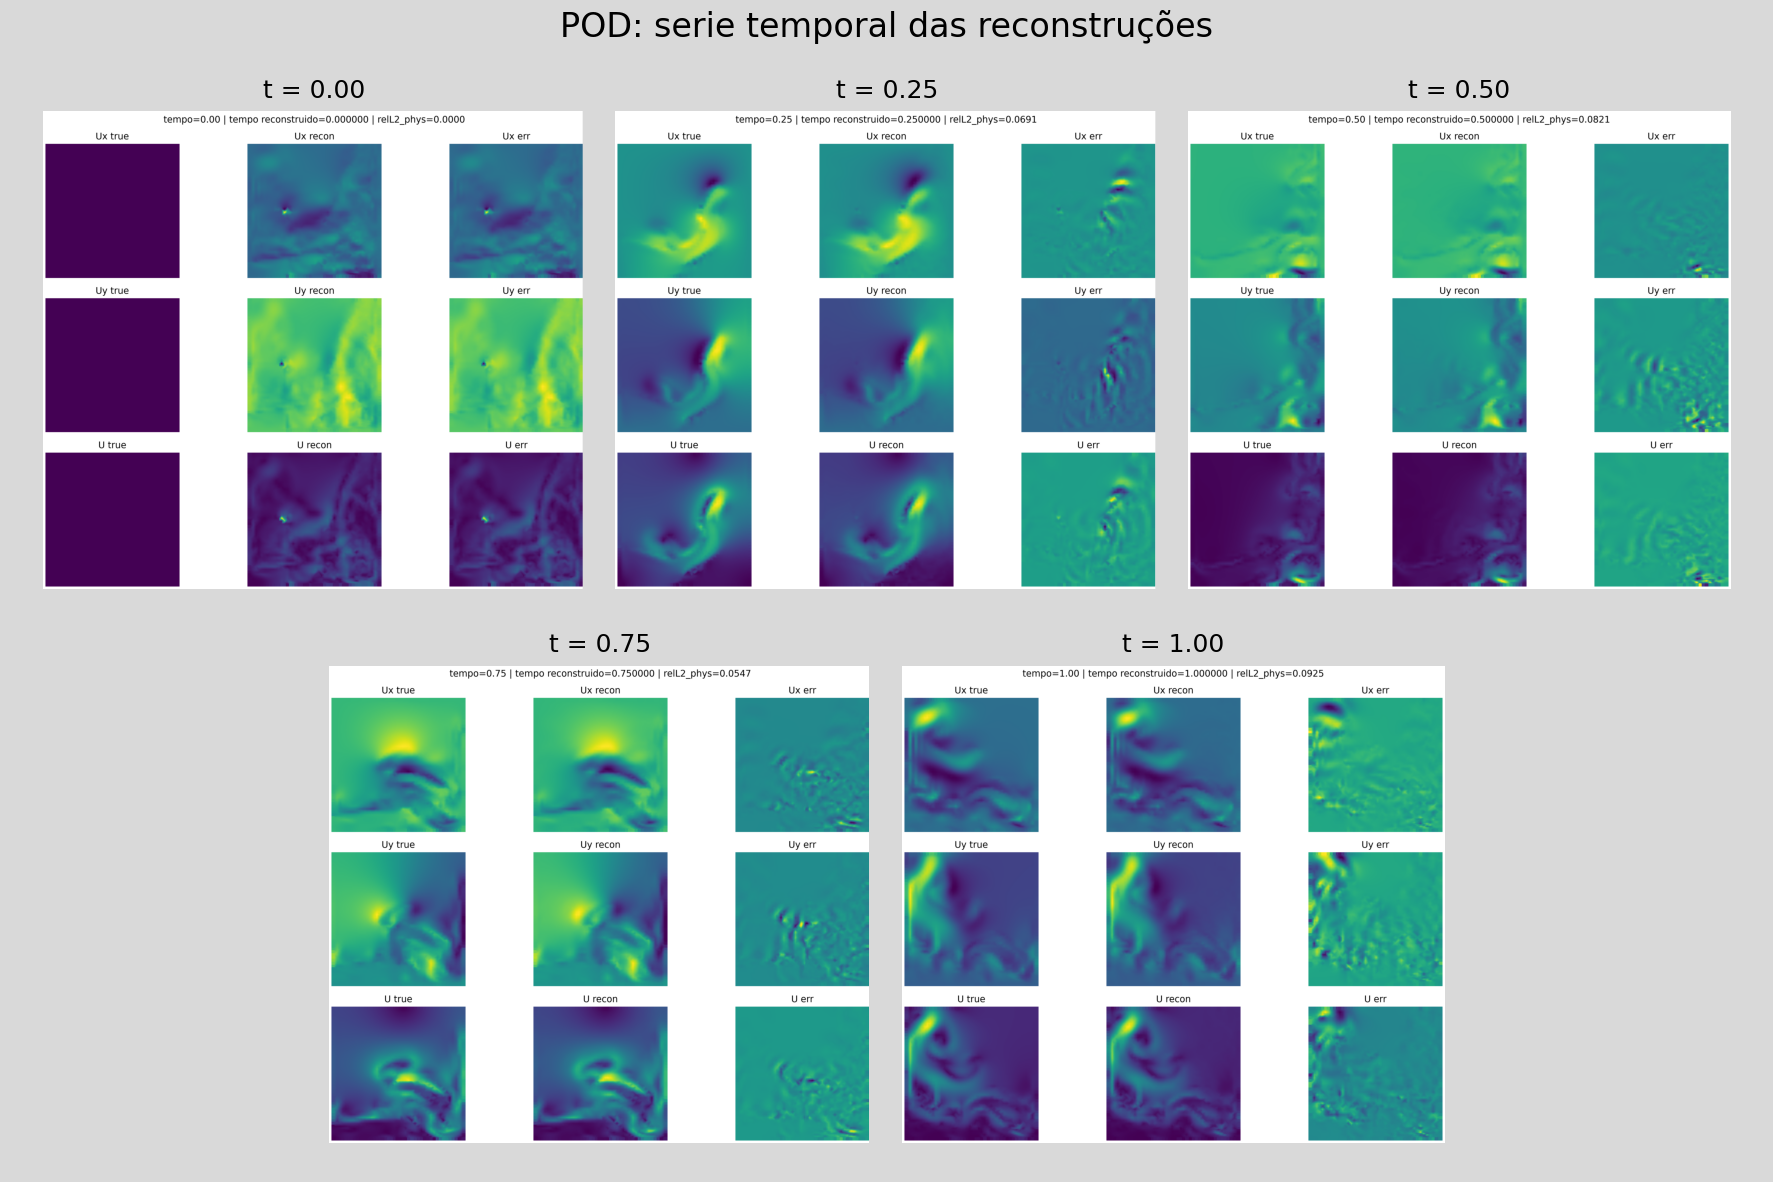


[SALVO] C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\tempos_0a_1_pod_20260512_164623_253606\serie_temporal_pod_3_em_cima_2_embaixo.png


In [2]:
# ============================================================
# POD: montar serie temporal com 3 imagens em cima e 2 embaixo
# com recorte suave e fundo cinza uniforme
# ============================================================
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import FancyBboxPatch

img_dir = Path(r"C:\Users\eldoj\OneDrive\Documentos\SAE-POD-SINDy-main\damBreakLaminar1000\POD\resultados\tempos_0a_1_pod_20260512_164623_253606")
out_path = img_dir / "serie_temporal_pod_3_em_cima_2_embaixo.png"

if not img_dir.exists():
    raise FileNotFoundError(f"Pasta nao encontrada: {img_dir}")

img_paths = sorted(img_dir.glob("pod_tempo_*_phys.png"))
if not img_paths:
    raise RuntimeError(f"Nenhuma imagem 'pod_tempo_*_phys.png' encontrada em: {img_dir}")

def extract_time(path: Path) -> float:
    m = re.search(r"pod_tempo_(\d+)p(\d+)_phys\.png$", path.name)
    if m is None:
        return np.inf
    return float(f"{m.group(1)}.{m.group(2)}")

def crop_white_border_soft(
    img: np.ndarray,
    white_thr: float = 0.992,
    pad_top: int = 18,
    pad_bottom: int = 10,
    pad_left: int = 10,
    pad_right: int = 10,
) -> np.ndarray:
    arr = np.asarray(img)

    if arr.dtype.kind in "ui":
        arr = arr.astype(np.float32) / 255.0
    else:
        arr = arr.astype(np.float32)

    if arr.ndim == 2:
        gray = arr
        alpha = np.ones_like(gray)
    elif arr.shape[2] == 4:
        gray = arr[..., :3].mean(axis=2)
        alpha = arr[..., 3]
    else:
        gray = arr[..., :3].mean(axis=2)
        alpha = np.ones_like(gray)

    mask = (gray < white_thr) & (alpha > 1e-6)

    if not np.any(mask):
        return img

    ys, xs = np.where(mask)
    y0 = max(int(ys.min()) - pad_top, 0)
    y1 = min(int(ys.max()) + pad_bottom + 1, arr.shape[0])
    x0 = max(int(xs.min()) - pad_left, 0)
    x1 = min(int(xs.max()) + pad_right + 1, arr.shape[1])

    return img[y0:y1, x0:x1]

img_paths = sorted(img_paths, key=extract_time)
times = [extract_time(p) for p in img_paths]

if len(img_paths) != 5:
    raise RuntimeError(
        f"Este bloco foi feito para 5 imagens. Encontradas: {len(img_paths)} em {img_dir}"
    )

print("Imagens encontradas em ordem temporal:")
for p, tt in zip(img_paths, times):
    print(f"  t={tt:.2f} -> {p.name}")

cropped_images = [
    crop_white_border_soft(
        mpimg.imread(p),
        white_thr=0.992,
        pad_top=18,
        pad_bottom=10,
        pad_left=10,
        pad_right=10,
    )
    for p in img_paths
]

bg_color = "#d9d9d9"

fig = plt.figure(figsize=(18, 12), facecolor=bg_color)
gs = fig.add_gridspec(2, 6)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
]

for ax, img, tt in zip(axes, cropped_images, times):
    card = FancyBboxPatch(
        (-0.04, -0.04), 1.08, 1.08,
        boxstyle="round,pad=0.02",
        transform=ax.transAxes,
        facecolor=bg_color,
        edgecolor="none",
        zorder=-10,
        clip_on=False,
    )
    ax.add_patch(card)

    ax.imshow(img)
    ax.set_title(f"t = {tt:.2f}", fontsize=18, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor(bg_color)

    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("POD: serie temporal das reconstruções", fontsize=24, y=0.985)

plt.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.90,
    bottom=0.04,
    wspace=0.10,
    hspace=0.16,
)

fig.savefig(
    out_path,
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.04,
    facecolor=fig.get_facecolor(),
)
plt.show()

print(f"\n[SALVO] {out_path}")
